In [1]:
# Install required packages
!pip install nltk python-Levenshtein matplotlib torch torchvision torchaudio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.9/159.9 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 103.4 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import math
import random
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import Levenshtein


In [3]:
# Download NLTK data
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [4]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.8.0+cu126
CUDA available: True


In [5]:

# ====================================================================
#  Configuration
# ====================================================================

class Config:
    """
    Architecture specification:
    - Encoder:LSTM  (bidirectional)
    - Decoder:LSTM (unidirectional)
    """
    # Data
    DATA_PATH = "/content/drive/MyDrive/TensorData/padded_dataset.pt"

    # Model Architecture
    EMBEDDING_DIM = 512      # Size of word embeddings
    HIDDEN_SIZE = 256        # LSTM hidden state size
    ENCODER_LAYERS = 2
    DECODER_LAYERS = 4
    DROPOUT = 0.3           # Regularization

    # Training Parameters
    LEARNING_RATE = 1e-3
    BATCH_SIZE = 32

    # Phase 1: Frozen Encoder Training
    PHASE1_EPOCHS = 15      # Train decoder only

    # Phase 2: Full Training
    PHASE2_EPOCHS = 30      # Train encoder + decoder
    PHASE2_LR_FACTOR = 0.1  # Reduce LR for fine-tuning

    # System
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

# Set random seeds for reproducibility
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
random.seed(Config.SEED)



In [6]:

# ====================================================================
# Load Data
# ====================================================================


def load_data():
    """
    Load the preprocessed dataset

    Returns:
        dict: Contains all data components with their dimensions
    """
    print(f"Path: {Config.DATA_PATH}")

    try:
        data = torch.load(Config.DATA_PATH)
        print("Data loaded successfully!")
    except FileNotFoundError:
        print("Dataset not found! Please check the path.")
        return None

    # Extract components
    src_tensor = data["src_tensor"]     # Urdu tokens
    src_lengths = data["src_lengths"]
    tgt_tensor = data["tgt_tensor"]     # Roman tokens
    tgt_lengths = data["tgt_lengths"]
    vocab_src = data["vocab_src"]       # Urdu vocabulary
    vocab_tgt = data["vocab_tgt"]       # Roman vocabulary

    # Create reverse mappings for decoding
    id2tgt = {i: token for token, i in vocab_tgt.items()}
    id2src = {i: token for token, i in vocab_src.items()}

    # Get special token indices
    PAD_SRC = vocab_src["<pad>"]
    PAD_TGT = vocab_tgt["<pad>"]
    SOS_TGT = vocab_tgt.get("<sos>")
    EOS_TGT = vocab_tgt.get("<eos>")

    print("\nDataset Information:")
    print(f"  Number of samples: {src_tensor.size(0):,}")
    print(f"  Source vocab size: {len(vocab_src):,}")
    print(f"  Target vocab size: {len(vocab_tgt):,}")
    print(f"  Special tokens - PAD_SRC: {PAD_SRC}, PAD_TGT: {PAD_TGT}")
    print(f"  Special tokens - SOS_TGT: {SOS_TGT}, EOS_TGT: {EOS_TGT}")

    # Show tensor dimensions
    print(f"\nTensor Dimensions:")
    print(f"  src_tensor: {src_tensor.shape}")
    print(f"  tgt_tensor: {tgt_tensor.shape}")
    print(f"  src_lengths: {src_lengths.shape}")
    print(f"  tgt_lengths: {tgt_lengths.shape}")

    return {
        'src_tensor': src_tensor, 'src_lengths': src_lengths,
        'tgt_tensor': tgt_tensor, 'tgt_lengths': tgt_lengths,
        'vocab_src': vocab_src, 'vocab_tgt': vocab_tgt,
        'id2src': id2src, 'id2tgt': id2tgt,
        'PAD_SRC': PAD_SRC, 'PAD_TGT': PAD_TGT,
        'SOS_TGT': SOS_TGT, 'EOS_TGT': EOS_TGT
    }


In [7]:

# Load the data
data = load_data()


Path: /content/drive/MyDrive/TensorData/padded_dataset.pt
Data loaded successfully!

Dataset Information:
  Number of samples: 20,856
  Source vocab size: 512
  Target vocab size: 512
  Special tokens - PAD_SRC: 3, PAD_TGT: 14
  Special tokens - SOS_TGT: 15, EOS_TGT: 13

Tensor Dimensions:
  src_tensor: torch.Size([20856, 41])
  tgt_tensor: torch.Size([20856, 48])
  src_lengths: torch.Size([20856])
  tgt_lengths: torch.Size([20856])


In [8]:

# ====================================================================
#  Dataset Class
# ====================================================================

class TransliterationDataset(Dataset):
    """
    Custom Dataset for Urdu-Roman transliteration

    Each sample contains:
    - src: Urdu sequence (input)
    - tgt: Roman sequence (target output)
    - src_len: Actual length of source (excluding padding)
    - tgt_len: Actual length of target (excluding padding)
    """
    def __init__(self, src_tensor, tgt_tensor, src_lengths, tgt_lengths):
        self.src_tensor = src_tensor
        self.tgt_tensor = tgt_tensor
        self.src_lengths = src_lengths
        self.tgt_lengths = tgt_lengths

        print(f"Dataset created with {len(self)} samples")

    def __len__(self):
        return len(self.src_tensor)

    def __getitem__(self, idx):
        return {
            'src': self.src_tensor[idx],      # Shape: (max_src_len,)
            'tgt': self.tgt_tensor[idx],      # Shape: (max_tgt_len,)
            'src_len': self.src_lengths[idx], # Scalar
            'tgt_len': self.tgt_lengths[idx]  # Scalar
        }

In [9]:
# Create the dataset
dataset = TransliterationDataset(
    data['src_tensor'], data['tgt_tensor'],
    data['src_lengths'], data['tgt_lengths']
)

Dataset created with 20856 samples


In [10]:
# Show a sample
print("\nSample data point:")
sample = dataset[0]
print(f"   Source shape: {sample['src'].shape}")
print(f"   Target shape: {sample['tgt'].shape}")
print(f"   Source length: {sample['src_len']}")
print(f"   Target length: {sample['tgt_len']}")

# ==


Sample data point:
   Source shape: torch.Size([41])
   Target shape: torch.Size([48])
   Source length: 15
   Target length: 13


In [11]:

# ====================================================================
# Data Splitting
# ====================================================================

def create_data_splits(dataset, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Split dataset into train/validation/test sets
    """

    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    val_size = int(val_ratio * total_size)
    test_size = total_size - train_size - val_size

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(Config.SEED)
    )

    print("Dataset splits:")
    print(f"  Train: {len(train_dataset):,} ({len(train_dataset)/total_size*100:.1f}%)")
    print(f"  Validation: {len(val_dataset):,} ({len(val_dataset)/total_size*100:.1f}%)")
    print(f"  Test: {len(test_dataset):,} ({len(test_dataset)/total_size*100:.1f}%)")

    return train_dataset, val_dataset, test_dataset


In [12]:

# Create splits
train_dataset, val_dataset, test_dataset = create_data_splits(dataset)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

print(f"\nData loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

# Show batch dimensions
sample_batch = next(iter(train_loader))
print(f"\nBatch dimensions:")
print(f"  src batch: {sample_batch['src'].shape}")  # (batch_size, max_src_len)
print(f"  tgt batch: {sample_batch['tgt'].shape}")  # (batch_size, max_tgt_len)


Dataset splits:
  Train: 14,599 (70.0%)
  Validation: 3,128 (15.0%)
  Test: 3,129 (15.0%)

Data loaders created:
  Train batches: 457
  Val batches: 98
  Test batches: 98

Batch dimensions:
  src batch: torch.Size([32, 41])
  tgt batch: torch.Size([32, 48])


In [23]:
# ====================================================================
# Encoder Architecture
# ====================================================================

class BiLSTMEncoder(nn.Module):
    """
    Bidirectional LSTM Encoder

    - Bidirectional (processes sequence left→right and right→left)
    - Projects bidirectional outputs to decoder hidden size

    Gradient Flow
    - Encoder parameters W(e) receive gradients through decoder initialization
    - Each layer receives gradients from layers above it
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, dropout, pad_idx):
        super(BiLSTMEncoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # print(f"Building Encoder:")
        # print(f"  Vocab size: {vocab_size:,}")
        # print(f"  Embedding dim: {embedding_dim}")
        # print(f"  Hidden size: {hidden_size}")
        # print(f"  Layers: {num_layers}")

        # Word embeddings
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)

        # Bidirectional LSTM (each direction has hidden_size units)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,  # Creates 2*hidden_size outputs
            dropout=dropout if num_layers > 1 else 0
        )

        # Project bidirectional states (2*hidden_size) → decoder size (hidden_size)
        #self.hidden_projection = nn.Linear(hidden_size * 2, hidden_size)
        #self.cell_projection = nn.Linear(hidden_size * 2, hidden_size)

        # print(f"  Bidirectional: True (output size: {hidden_size * 2})")
        # print(f"  Projection: {hidden_size * 2} → {hidden_size}")

    def forward(self, src, src_lengths):
        """
        Forward pass with dimension tracking

        Input:
            src: (batch_size, max_src_len) - token indices
            src_lengths: (batch_size,) - actual sequence lengths

        Output:
            encoder_outputs: (batch_size, max_src_len, hidden_size*2) - all timestep outputs
            (hidden, cell): Each (num_layers, batch_size, hidden_size) - final states for decoder
        """
        batch_size = src.size(0)
        max_len = src.size(1)

        # print(f"\nEncoder Forward Pass:")
        # print(f"  Input src: {src.shape}")
        # print(f"  Input lengths: {src_lengths.shape}")

        # Step 1: Embedding lookup
        embedded = self.dropout(self.embedding(src))
        # print(f"  After embedding: {embedded.shape}")

        # Step 2: Pack sequences for efficiency (handles variable lengths)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # Step 3: BiLSTM processing
        packed_output, (hidden, cell) = self.lstm(packed)
        # print(f"  LSTM hidden states: {hidden.shape}")  # (num_layers*2, batch, hidden_size)
        # print(f"  LSTM cell states: {cell.shape}")

        # Step 4: Unpack sequences
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        # print(f"  Unpacked output: {output.shape}")  # (batch, max_len, hidden_size*2)

        # Step 5: Reshape bidirectional states
        # From: (num_layers*2, batch, hidden_size) → (num_layers, 2, batch, hidden_size)
        hidden = hidden.view(self.num_layers, 2, batch_size, self.hidden_size)
        cell = cell.view(self.num_layers, 2, batch_size, self.hidden_size)

        # Step 6: Concatenate forward and backward states
        hidden = torch.cat((hidden[:, 0], hidden[:, 1]), dim=2)  # (num_layers, batch, hidden_size*2)
        cell = torch.cat((cell[:, 0], cell[:, 1]), dim=2)
        # print(f"  Concatenated states: {hidden.shape}")

        # Step 7: Project to decoder hidden size
        #hidden = self.hidden_projection(hidden)  # (num_layers, batch, hidden_size)
        #cell = self.cell_projection(cell)
        # print(f"  Projected states: {hidden.shape}")

        return output, (hidden, cell)


In [24]:

# ====================================================================
# Decoder Architecture
# ====================================================================

class LSTMDecoder(nn.Module):
    """
    LSTM Decoder with Teacher Forcing

    - Takes previous target token as input
    - Outputs probability distribution over vocabulary

    Gradient Flow :
    - Decoder parameters W(d) shape error signal ∂L/∂h
    - This error signal propagates back to encoder
    - Each layer receives gradients from output and layers above
    """
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, dropout, pad_idx):
        super(LSTMDecoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.vocab_size = vocab_size


        # print(f"Building decoder:")
        # print(f"  Vocab size: {vocab_size:,}")
        # print(f"  Embedding dim: {embedding_dim}")
        # print(f"  Hidden size: {hidden_size}")
        # print(f"  Layers: {num_layers}")

        # Word embeddings (shared vocabulary with encoder output)
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)

        # 4-layer LSTM (as specified in PDF)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Output projection to vocabulary
        self.out = nn.Linear(hidden_size, vocab_size)
        # print(f"  Output projection: {hidden_size} → {vocab_size:,}")

    def forward(self, tgt, hidden, cell):
        """
        Forward pass with teacher forcing

        Input:
            tgt: (batch_size, seq_len) - target tokens (shifted input)
            hidden: (num_layers, batch_size, hidden_size) - initial hidden states
            cell: (num_layers, batch_size, hidden_size) - initial cell states

        Output:
            output: (batch_size, seq_len, vocab_size) - logits for each position
            (hidden, cell): Updated states for next timestep
        """
        # print(f"\nDecoder Forward Pass:")
        # print(f"  Input tgt: {tgt.shape}")
        # print(f"  Hidden: {hidden.shape}")
        # print(f"  Cell: {cell.shape}")

        # Step 1: Embedding lookup
        embedded = self.dropout(self.embedding(tgt))
        # print(f"  After embedding: {embedded.shape}")

        # Step 2: LSTM processing
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # print(f"  LSTM output: {output.shape}")
        # print(f"  Updated hidden: {hidden.shape}")

        # Step 3: Project to vocabulary
        output = self.out(output)
        # print(f"  Final logits: {output.shape}")

        return output, (hidden, cell)


In [25]:

# ====================================================================
# Complete Seq2Seq Model
# ====================================================================

class Seq2SeqModel(nn.Module):
    """
    Complete Sequence-to-Sequence Model with Teacher Forcing Ratio

    - Phase 1: 100% teacher forcing (use ground truth)
    - Phase 2: Scheduled sampling (gradually reduce teacher forcing)
    - Gradient flow: W(d) parameters shape error signal for encoder
    """
    def __init__(self, src_vocab_size, tgt_vocab_size, embedding_dim, hidden_size,
                 encoder_layers, decoder_layers, dropout, src_pad_idx, tgt_pad_idx):
        super(Seq2SeqModel, self).__init__()

        # Build encoder and decoder
        self.encoder = BiLSTMEncoder(
            src_vocab_size, embedding_dim, hidden_size,
            encoder_layers, dropout, src_pad_idx
        )

        self.decoder = LSTMDecoder(
            tgt_vocab_size, embedding_dim, hidden_size*2,
            decoder_layers, dropout, tgt_pad_idx
        )

        # State initialization layers (encoder → decoder)
        self.init_hidden = nn.Linear(hidden_size*2, hidden_size*2)
        self.init_cell = nn.Linear(hidden_size*2, hidden_size*2)

        self.tgt_pad_idx = tgt_pad_idx

        # Count parameters
        total_params = sum(p.numel() for p in self.parameters())
        encoder_params = sum(p.numel() for p in self.encoder.parameters())
        decoder_params = sum(p.numel() for p in self.decoder.parameters())

        print(f"  Total parameters: {total_params:,}")
        print(f"  Encoder parameters: {encoder_params:,}")
        print(f"  Decoder parameters: {decoder_params:,}")
        print(f"  Init parameters: {total_params - encoder_params - decoder_params:,}")

    def forward(self, src, tgt, src_lengths, tgt_lengths, teacher_forcing_ratio=1.0):
        """
        Complete forward pass with teacher forcing ratio

        Args:
            src: (batch_size, max_src_len) - source sequences
            tgt: (batch_size, max_tgt_len) - target sequences (with <sos>)
            src_lengths: (batch_size,) - actual source lengths
            tgt_lengths: (batch_size,) - actual target lengths
            teacher_forcing_ratio: float - probability of using ground truth (0.0 to 1.0)

        Output:
            outputs: (batch_size, max_tgt_len-1, vocab_size) - predictions
        """
        batch_size = src.size(0)
        max_tgt_len = tgt.size(1) - 1  # Exclude <sos> from output length
        vocab_size = self.decoder.vocab_size
        device = src.device

        # print(f"\nSeq2Seq Forward Pass:")
        # print(f"  Source: {src.shape}")
        # print(f"  Target: {tgt.shape}")
        # print(f"  Teacher Forcing Ratio: {teacher_forcing_ratio:.2f}")

        # Step 1: Encode source sequence
        encoder_outputs, (encoder_hidden, encoder_cell) = self.encoder(src, src_lengths)
        # print(f"  Encoder outputs: {encoder_outputs.shape}")  # All timesteps
        # print(f"  Encoder states: {encoder_hidden.shape}")    # Final states only

        # Step 2: Initialize decoder states from encoder
        decoder_hidden = torch.zeros(self.decoder.num_layers, batch_size,
                                   self.decoder.hidden_size, device=device)
        decoder_cell = torch.zeros(self.decoder.num_layers, batch_size,
                                 self.decoder.hidden_size, device=device)

        # Use encoder final states for decoder initialization
        decoder_hidden[0] = self.init_hidden(encoder_hidden[-1])
        decoder_cell[0] = self.init_cell(encoder_cell[-1])

        # print(f"  Initialized decoder states: {decoder_hidden.shape}")

                # Step 3: Decode with teacher forcing ratio
        outputs = torch.zeros(batch_size, max_tgt_len, vocab_size, device=device)

        # Instead of starting with <sos> from target, start with <pad>-aligned src
        # Pad src to match max_tgt_len
        padded_src = torch.full((batch_size, max_tgt_len+1), self.tgt_pad_idx, device=device)
        padded_src[:, :src.size(1)] = src  # copy src into padded tensor

        # Use src as decoder input instead of tgt
        decoder_input = padded_src[:, 0].unsqueeze(1)

        for t in range(max_tgt_len):
            output, (decoder_hidden, decoder_cell) = self.decoder(
                decoder_input, decoder_hidden, decoder_cell
            )
            outputs[:, t:t+1, :] = output

            # Same teacher forcing logic, but now using src instead of tgt
            use_teacher_forcing = random.random() < teacher_forcing_ratio

            if use_teacher_forcing and t < max_tgt_len - 1:
                decoder_input = padded_src[:, t+1].unsqueeze(1)  # next src token
            else:
                predicted_token = output.argmax(dim=-1)
                decoder_input = predicted_token

                # input_source = "prediction"

            # # Print first few steps for debugging
            # if t < 3:
            #     print(f"    Step {t}: using {input_source}")

        # print(f"  Final outputs: {outputs.shape}")
        return outputs



In [26]:
# Initializing Seq2Seq Model...

#   Total parameters: 45,140,480
#   Encoder parameters: 10,764,288
#   Decoder parameters: 32,276,992
#   Init parameters: 2,099,200

# Model created and moved to cpu

# Testing model with sample batch...

# Seq2Seq Forward Pass:
#   Source: torch.Size([32, 41])
#   Target: torch.Size([32, 48])
#   Teacher Forcing Ratio: 1.00

# Encoder Forward Pass:
#   Input src: torch.Size([32, 41])
#   Input lengths: torch.Size([32])
#   After embedding: torch.Size([32, 41, 512])
#   LSTM hidden states: torch.Size([4, 32, 512])
#   LSTM cell states: torch.Size([4, 32, 512])
#   Unpacked output: torch.Size([32, 28, 1024])
#   Concatenated states: torch.Size([2, 32, 1024])
#   Projected states: torch.Size([2, 32, 1024])
#   Encoder outputs: torch.Size([32, 28, 1024])
#   Encoder states: torch.Size([2, 32, 1024])
#   Initialized decoder states: torch.Size([4, 32, 1024])

# Decoder Forward Pass:
#   Input tgt: torch.Size([32, 1])
#   Hidden: torch.Size([4, 32, 1024])
#   Cell: torch.Size([4, 32, 1024])
#   After embedding: torch.Size([32, 1, 512])
#   LSTM output: torch.Size([32, 1, 1024])
#   Updated hidden: torch.Size([4, 32, 1024])
#   Final logits: torch.Size([32, 1, 512])
#     Step 0: using ground_truth

# Decoder Forward Pass:
#   Input tgt: torch.Size([32, 1])
#   Hidden: torch.Size([4, 32, 1024])
#   Cell: torch.Size([4, 32, 1024])
#   After embedding: torch.Size([32, 1, 512])
#   LSTM output: torch.Size([32, 1, 1024])
#   Updated hidden: torch.Size([4, 32, 1024])
#   Final logits: torch.Size([32, 1, 512])
#     Step 1: using ground_truth


# Decoder Forward Pass:
#   Input tgt: torch.Size([32, 1])
#   Hidden: torch.Size([4, 32, 1024])
#   Cell: torch.Size([4, 32, 1024])
#   After embedding: torch.Size([32, 1, 512])
#   LSTM output: torch.Size([32, 1, 1024])
#   Updated hidden: torch.Size([4, 32, 1024])
#   Final logits: torch.Size([32, 1, 512])

# Decoder Forward Pass:
#   Input tgt: torch.Size([32, 1])
#   Hidden: torch.Size([4, 32, 1024])
#   Cell: torch.Size([4, 32, 1024])
#   After embedding: torch.Size([32, 1, 512])
#   LSTM output: torch.Size([32, 1, 1024])
#   Updated hidden: torch.Size([4, 32, 1024])
#   Final logits: torch.Size([32, 1, 512])
#   Final outputs: torch.Size([32, 47, 512])
# Test successful! Output shape: torch.Size([32, 47, 512])

In [27]:

# ====================================================================
# CELL 9: Initialize Model
# ====================================================================

# Create the model
print("Initializing Seq2Seq Model...")

model = Seq2SeqModel(
    src_vocab_size=len(data['vocab_src']),
    tgt_vocab_size=len(data['vocab_tgt']),
    embedding_dim=Config.EMBEDDING_DIM,
    hidden_size=Config.HIDDEN_SIZE,
    encoder_layers=Config.ENCODER_LAYERS,
    decoder_layers=Config.DECODER_LAYERS,
    dropout=Config.DROPOUT,
    src_pad_idx=data['PAD_SRC'],
    tgt_pad_idx=data['PAD_TGT']
).to(Config.DEVICE)
print(f"\nModel created and moved to {Config.DEVICE}")

#Test model with a small batch
print("\nTesting model with sample batch...")
sample_batch = next(iter(train_loader))
src = sample_batch['src'].to(Config.DEVICE)
tgt = sample_batch['tgt'].to(Config.DEVICE)
src_lengths = sample_batch['src_len']
tgt_lengths = sample_batch['tgt_len']

with torch.no_grad():
    output = model(src, tgt, src_lengths, tgt_lengths)
    print(f"Test successful! Output shape: {output.shape}")


Initializing Seq2Seq Model...
  Total parameters: 12,871,168
  Encoder parameters: 3,416,064
  Decoder parameters: 8,929,792
  Init parameters: 525,312

Model created and moved to cuda

Testing model with sample batch...
Test successful! Output shape: torch.Size([32, 47, 512])


In [28]:

# ====================================================================
# Evaluation Metrics
# ====================================================================

def calculate_accuracy(predictions, targets, id2tgt, pad_idx):
    """
    Calculate exact match accuracy (sequence-level)
    """
    correct = 0
    total = 0

    for pred, target in zip(predictions, targets):
        # Convert to tokens and remove padding
        pred_tokens = [id2tgt.get(idx.item(), '<unk>') for idx in pred]
        target_tokens = [id2tgt.get(idx.item(), '<unk>') for idx in target]

        # Remove padding and special tokens
        pred_clean = [t for t in pred_tokens if t not in ['<pad>', '<sos>', '<eos>']]
        target_clean = [t for t in target_tokens if t not in ['<pad>', '<sos>', '<eos>']]

        # Exact match
        if pred_clean == target_clean:
            correct += 1
        total += 1

    return correct / total if total > 0 else 0.0

def calculate_bleu(predictions, targets, id2tgt):
    """
    Calculate BLEU score (n-gram overlap)
    """
    bleu_scores = []
    smooth_func = SmoothingFunction().method1

    for pred, target in zip(predictions, targets):
        pred_tokens = [id2tgt.get(idx.item(), '<unk>') for idx in pred]
        target_tokens = [id2tgt.get(idx.item(), '<unk>') for idx in target]

        # Clean tokens
        pred_tokens = [t for t in pred_tokens if t not in ['<pad>', '<sos>', '<eos>']]
        target_tokens = [t for t in target_tokens if t not in ['<pad>', '<sos>', '<eos>']]

        if len(pred_tokens) > 0 and len(target_tokens) > 0:
            score = sentence_bleu([target_tokens], pred_tokens, smoothing_function=smooth_func)
            bleu_scores.append(score)

    return np.mean(bleu_scores) if bleu_scores else 0.0

def calculate_cer(predictions, targets, id2tgt):
    """
    Calculate Character Error Rate using edit distance
    """
    distances = []

    for pred, target in zip(predictions, targets):
        pred_str = ''.join([id2tgt.get(idx.item(), '') for idx in pred])
        target_str = ''.join([id2tgt.get(idx.item(), '') for idx in target])

        # Clean strings
        pred_str = pred_str.replace('<pad>', '').replace('<sos>', '').replace('<eos>', '')
        target_str = target_str.replace('<pad>', '').replace('<sos>', '').replace('<eos>', '')

        if len(target_str) > 0:
            distance = Levenshtein.distance(pred_str, target_str) / len(target_str)
            distances.append(distance)

    return np.mean(distances) if distances else 1.0

def calculate_perplexity(loss):
    """
    Calculate perplexity from cross-entropy loss
    """
    return math.exp(min(loss, 20))  # Cap to prevent overflow

print("Evaluation metrics")
print("   Accuracy: Exact sequence match")
print("   BLEU: N-gram overlap score")
print("   CER: Character-level edit distance")
print("   Perplexity: Language model confidence")


Evaluation metrics
   Accuracy: Exact sequence match
   BLEU: N-gram overlap score
   CER: Character-level edit distance
   Perplexity: Language model confidence


In [29]:

# ====================================================================
# Model Evaluation Function
# ====================================================================

def evaluate_model(model, dataloader, criterion, id2tgt, device, desc="Evaluation",teacher_forcing_ratio=0.0):
    """
    🧪 Comprehensive model evaluation

    Returns dictionary with all metrics
    """
    model.eval()
    total_loss = 0
    all_predictions = []
    all_targets = []

    print(f"\n{desc} (Teacher Forcing: {teacher_forcing_ratio:.3f})...")

    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)
            src_lengths = batch['src_len']
            tgt_lengths = batch['tgt_len']

            # Forward pass with specified teacher forcing ratio
            outputs = model(src, tgt, src_lengths, tgt_lengths,
                          teacher_forcing_ratio=teacher_forcing_ratio)

            # Calculate loss
            loss = criterion(outputs.reshape(-1, outputs.size(-1)),
                           tgt[:, 1:].reshape(-1))
            total_loss += loss.item()

            # Get predictions
            predictions = torch.argmax(outputs, dim=-1)

            # Store for metric calculation
            all_predictions.extend(predictions.cpu())
            all_targets.extend(tgt[:, 1:].cpu())

            if batch_idx % 50 == 0:
                print(f"   Processed {batch_idx}/{len(dataloader)} batches")

    # Calculate metrics
    avg_loss = total_loss / len(dataloader)
    perplexity = calculate_perplexity(avg_loss)
    accuracy = calculate_accuracy(all_predictions, all_targets, id2tgt, data['PAD_TGT'])
    bleu = calculate_bleu(all_predictions, all_targets, id2tgt)
    cer = calculate_cer(all_predictions, all_targets, id2tgt)

    metrics = {
        'loss': avg_loss,
        'perplexity': perplexity,
        'accuracy': accuracy,
        'bleu': bleu,
        'cer': cer
    }

    print(f"\n {desc} Results:")
    print(f"   Loss: {avg_loss:.4f}")
    print(f"   Perplexity: {perplexity:.4f}")
    print(f"   Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   BLEU: {bleu:.4f}")
    print(f"   CER: {cer:.4f}")

    return metrics


In [30]:
def test_single_sample_and_check_metrics(model, dataset, id2src, id2tgt, device, pad_idx, idx=0, criterion=None):
    """
    Runs one sample through model, prints src/tgt/pred tokens,
    then computes metrics for model prediction and also for a perfect prediction
    (prediction == target) to verify metrics return expected perfect scores.
    """
    import torch
    model.eval()

    # get sample (dataset returns a dict)
    sample = dataset[idx]
    src = sample['src'].unsqueeze(0)         # [1, src_len]
    tgt = sample['tgt'].unsqueeze(0)         # [1, tgt_len]
    src_lengths = sample['src_len'].unsqueeze(0)
    tgt_lengths = sample['tgt_len'].unsqueeze(0)

    with torch.no_grad():
        outputs = model(src.to(device), tgt.to(device), src_lengths, tgt_lengths,teacher_forcing_ratio=1)
        # outputs shape: [1, tgt_len-1, vocab_size]
        preds = outputs.argmax(dim=-1).cpu()   # [1, tgt_len-1]

    # Prepare token lists (include special tokens so we can clean them)
    def ids_to_tokens(ids_tensor, id2map):
        return [id2map.get(int(i), '<unk>') for i in ids_tensor]

    # predicted tokens (preds covers positions corresponding to tgt[:,1:])
    pred_tokens = ids_to_tokens(preds[0], id2tgt)
    target_tokens = ids_to_tokens(tgt[0], id2tgt)   # skip <sos> as used in training
    src_tokens = ids_to_tokens(src[0], id2src)

    def clean(tokens):
        return [t for t in tokens if t not in ('')]

    print("\n--- Single Sample Debug ---")
    print("SRC :", " ".join(clean(src_tokens)))
    print("TGT :", " ".join(clean(target_tokens)))
    print("PRED:", " ".join(clean(pred_tokens)))

    # Compute metrics on model prediction (wrap in lists to match your metric fns)
    acc = calculate_accuracy([preds[0]], [tgt[0, 1:]], id2tgt, pad_idx)
    bleu = calculate_bleu([preds[0]], [tgt[0, 1:]], id2tgt)
    cer = calculate_cer([preds[0]], [tgt[0, 1:]], id2tgt)

    print("\nModel prediction metrics (single sample):")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  BLEU:     {bleu:.4f}")
    print(f"  CER:      {cer:.4f}")

    # ---- Test metrics on PERFECT prediction (prediction == target) ----
    perfect_pred = tgt[:, 1:].cpu()   # [1, seq_len]
    perfect_target = tgt[:, 1:].cpu()

    perfect_acc = calculate_accuracy([perfect_pred[0]], [perfect_target[0]], id2tgt, pad_idx)
    perfect_bleu = calculate_bleu([perfect_pred[0]], [perfect_target[0]], id2tgt)
    perfect_cer = calculate_cer([perfect_pred[0]], [perfect_target[0]], id2tgt)
    perfect_ppl = calculate_perplexity(0.0)  # if loss==0 → perplexity = exp(0)=1

    print("\nMetrics on PERFECT prediction (sanity check):")
    print(f"  Accuracy: {perfect_acc:.4f}  (expect 1.0)")
    print(f"  BLEU:     {perfect_bleu:.4f}  (expect 1.0)")
    print(f"  CER:      {perfect_cer:.4f}  (expect 0.0)")
    print(f"  Perplexity (loss=0): {perfect_ppl:.4f}  (expect 1.0)")

    # Optionally return both sets
    return {
        'model_metrics': {'acc': acc, 'bleu': bleu, 'cer': cer},
        'perfect_metrics': {'acc': perfect_acc, 'bleu': perfect_bleu, 'cer': perfect_cer, 'ppl': perfect_ppl}
    }

# Call it
results = test_single_sample_and_check_metrics(
    model=model,
    dataset=test_dataset,
    id2src=data['id2src'],
    id2tgt=data['id2tgt'],
    device=Config.DEVICE,
    pad_idx=data['PAD_TGT'],
    idx=0  # pick sample 0, change as needed
)

print("\nReturned results dict:")
print(results)



--- Single Sample Debug ---
SRC : <sos> _تمہ ار ے _پ ھول _اور _شب نم _ہم ار ی <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
TGT : <sos> tum ha re_ phuul_ aur_ sh ab nam_ ham ar i_ <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
PRED: z-e- z-e- z-e- z-e- m-e- m-e- m-e- m-e- z-e- z-e- z-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e-

Model prediction metrics (single sample):
  Accuracy: 0.0000
  BLEU:     0.0000
  CER:      5.5758

Metrics on PERFECT prediction (sanity check):
  Accuracy: 1.0000  (expect 1.0)
  BLEU:     1.0000  (expect 1.0)
  CER:      0.0000  (

In [31]:

# ====================================================================
# Training Function - Phase 1 (Frozen Encoder)
# ====================================================================

def train_phase1_frozen_encoder(model, train_loader, val_loader, optimizer, criterion,
                                epochs, device, id2tgt):
    """
    Phase 1: Train decoder only with 100% teacher forcing

    - Encoder parameters frozen
    - Always use ground truth sequence
    - Learn basic sequence-to-sequence mapping
    """
    print("\n" + "="*60)
    print("PHASE 1: FROZEN ENCODER + 100% TEACHER FORCING")
    print("="*60)
    print("Strategy: Decoder learns from perfect ground truth")
    print("Teacher Forcing Ratio: 1.0 (100% ground truth)")

    # Freeze encoder parameters
    print("\nFreezing encoder parameters...")
    frozen_params = 0
    trainable_params = 0

    for name, param in model.named_parameters():
        if 'encoder' in name:
            param.requires_grad = False
            frozen_params += param.numel()
        else:
            trainable_params += param.numel()

    print(f"   Frozen parameters: {frozen_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")

    # Training tracking
    train_losses = []
    val_losses = []
    val_metrics_history = []

    print(f"\nStarting Phase 1 training for {epochs} epochs...")

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        print(f"\nEpoch {epoch+1}/{epochs} - Training with 100% Teacher Forcing...")

        for batch_idx, batch in enumerate(train_loader):
            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)
            src_lengths = batch['src_len']
            tgt_lengths = batch['tgt_len']

            optimizer.zero_grad()

            # Forward pass with 100% teacher forcing
            outputs = model(src, tgt, src_lengths, tgt_lengths, teacher_forcing_ratio=1.0)

            # Calculate loss (ignore padding tokens)
            loss = criterion(outputs.reshape(-1, outputs.size(-1)),
                           tgt[:, 1:].reshape(-1))

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"   Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")

        # Calculate epoch metrics
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation (also with 100% teacher forcing for fair comparison)
        val_metrics = evaluate_model(model, val_loader, criterion, id2tgt, device,
                                              f"Validation Epoch {epoch+1}", teacher_forcing_ratio=1.0)
        val_losses.append(val_metrics['loss'])
        val_metrics_history.append(val_metrics)

        print(f"\nEpoch {epoch+1}/{epochs} Summary:")
        print(f"   Train Loss: {avg_train_loss:.4f}")
        print(f"   Val Loss: {val_metrics['loss']:.4f}")
        print(f"   Val Accuracy: {val_metrics['accuracy']:.4f}")
        print(f"   Val BLEU: {val_metrics['bleu']:.4f}")
        print("-" * 50)

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_metrics_history': val_metrics_history,
        'final_val_metrics': val_metrics
    }




In [42]:

# ====================================================================
# Training Function - Phase 2 (Unfrozen Full Training)
# ====================================================================

def train_phase2_unfrozen(model, train_loader, val_loader, optimizer, criterion,
                         epochs, device, id2tgt, lr_factor=0.1):
    """
    Phase 2: Full training with scheduled sampling

    - All parameters trainable
    - Teacher forcing ratio decays from 0.5 to 0.0
    - Gradually learn to use own predictions
    """
    print("\n" + "="*60)
    print("PHASE 2: FULL TRAINING + SCHEDULED SAMPLING")
    print("="*60)
    print("Strategy: Gradually reduce teacher forcing from 50% to 0%")
    print("Goal: Learn to generate from own predictions")

    # Unfreeze all parameters
    print("\nUnfreezing all parameters...")
    total_params = 0

    for param in model.parameters():
        param.requires_grad = True
        total_params += param.numel()

    print(f"   Total trainable parameters: {total_params:,}")

    # Reduce learning rate for fine-tuning
    original_lr = optimizer.param_groups[0]['lr']
    new_lr = 5e-4

    for param_group in optimizer.param_groups:
        param_group['lr'] = new_lr

    print(f"   Learning rate: {original_lr:.2e} -> {new_lr:.2e}")

    # Training tracking
    train_losses = []
    val_losses = []
    val_metrics_history = []

    print(f"\nStarting Phase 2 training for {epochs} epochs...")

    for epoch in range(epochs):
        # Calculate teacher forcing ratio (decay from 0.5 to 0.0)
        teacher_forcing_ratio = 1#max(0.0, 0.5 * (1.0 - epoch / 30  ))


        model.train()
        total_train_loss = 0

        print(f"\nEpoch {epoch+1}/{epochs} - Teacher Forcing Ratio: {teacher_forcing_ratio:.3f}")

        for batch_idx, batch in enumerate(train_loader):
            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)
            src_lengths = batch['src_len']
            tgt_lengths = batch['tgt_len']

            optimizer.zero_grad()

            # Forward pass with current teacher forcing ratio
            outputs = model(src, tgt, src_lengths, tgt_lengths,
                          teacher_forcing_ratio=teacher_forcing_ratio)

            # Calculate loss
            loss = criterion(outputs.reshape(-1, outputs.size(-1)),
                           tgt[:, 1:].reshape(-1))

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item()

            if batch_idx % 100 == 0:
                print(f"   Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}, TF: {teacher_forcing_ratio:.3f}")

        # Calculate epoch metrics
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation with same teacher forcing ratio
        val_metrics = evaluate_model(model, val_loader, criterion, id2tgt, device,
                                              f"Validation Epoch {epoch+1} (TF: {teacher_forcing_ratio:.3f})",
                                              teacher_forcing_ratio=teacher_forcing_ratio)
        val_losses.append(val_metrics['loss'])
        val_metrics_history.append(val_metrics)

        print(f"\nEpoch {epoch+1}/{epochs} Summary (TF: {teacher_forcing_ratio:.3f}):")
        print(f"   Train Loss: {avg_train_loss:.4f}")
        print(f"   Val Loss: {val_metrics['loss']:.4f}")
        print(f"   Val Accuracy: {val_metrics['accuracy']:.4f}")
        print(f"   Val BLEU: {val_metrics['bleu']:.4f}")
        print("-" * 50)

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_metrics_history': val_metrics_history,
        'final_val_metrics': val_metrics,
    }




In [33]:

# ====================================================================
# Show Translation Examples
# ====================================================================

def show_translation_examples(model, test_loader, id2src, id2tgt, device, num_examples=10,teacher_forcing_ratio=0):
    """
    🔍 Show qualitative examples of translations
    """
    model.eval()
    examples_shown = 0

    print("\n Translation Examples:")
    print("=" * 80)

    with torch.no_grad():
        for batch in test_loader:
            if examples_shown >= num_examples:
                break

            src = batch['src'].to(device)
            tgt = batch['tgt'].to(device)
            src_lengths = batch['src_len']
            tgt_lengths = batch['tgt_len']

            # Get model predictions
            outputs = model(src, tgt, src_lengths, tgt_lengths,teacher_forcing_ratio=teacher_forcing_ratio)
            predictions = torch.argmax(outputs, dim=-1)

            batch_size = min(src.size(0), num_examples - examples_shown)

            for i in range(batch_size):
                # Convert indices to tokens
                src_indices = src[i][:src_lengths[i]]  # Remove padding
                tgt_indices = tgt[i, 1:tgt_lengths[i]]  # Remove <sos> and padding
                pred_indices = predictions[i][:tgt_lengths[i]-1]  # Match target length

                # Convert to readable text
                src_tokens = [id2src.get(idx.item(), '<unk>') for idx in src_indices]
                tgt_tokens = [id2tgt.get(idx.item(), '<unk>') for idx in tgt_indices]
                pred_tokens = [id2tgt.get(idx.item(), '<unk>') for idx in pred_indices]

                # Join tokens (remove special tokens for display)
                src_text = ' '.join([t for t in src_tokens if t not in ['<pad>', '<sos>', '<eos>']])
                tgt_text = ' '.join([t for t in tgt_tokens if t not in ['<pad>', '<sos>', '<eos>']])
                pred_text = ' '.join([t for t in pred_tokens if t not in ['<pad>', '<sos>', '<eos>']])


                print(f"Example {examples_shown + 1}:")
                print(f"  Source (Urdu): {src_text}")
                print(f"  Ground Truth:  {tgt_text}")
                print(f"  Prediction:    {pred_text}")


                # Show character-level differences
                cer = Levenshtein.distance(pred_text, tgt_text) / max(len(tgt_text), 1)
                print(f"   📏 Character Error Rate: {cer:.3f}")

                print("-" * 60)

                examples_shown += 1
                if examples_shown >= num_examples:
                    break


In [34]:
# Show translation examples
show_translation_examples(
    model=model,
    test_loader=test_loader,
    id2src=data['id2src'],
    id2tgt=data['id2tgt'],
    device=Config.DEVICE,
    num_examples=10
)



 Translation Examples:
Example 1:
  Source (Urdu): _تمہ ار ے _پ ھول _اور _شب نم _ہم ار ی
  Ground Truth:  tum ha re_ phuul_ aur_ sh ab nam_ ham ar i_
  Prediction:    z-e- z-e- z-e- z-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e-
   📏 Character Error Rate: 1.116
------------------------------------------------------------
Example 2:
  Source (Urdu): _ض ب ط _دیکھ و _سب _کی _سن _ل ی _اور _کچھ _اپنی _کہ ی
  Ground Truth:  za b t_ dekh o_ sa b_ ki_ su n_ li _ aur_ kuchh_ apni_ ka hi_
  Prediction:    z-e- z-e- z-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e-
   📏 Character Error Rate: 1.197
------------------------------------------------------------
Example 3:
  Source (Urdu): _خو ر _شب نم _آش نا _نہ _ہوا _و ر نہ _میں _اس د ؔ
  Ground Truth:  kh ur_ sh ab na m- ash na_ na_ hua_ varna_ main_ 'asad'_
  Prediction:    z-e- z-e- z-e- z-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e- m-e-
   📏 Character Error Rate: 1.018
--------------------------------------------

In [35]:

# ====================================================================
# Initialize Training Components
# ====================================================================

# Loss function (ignores padding tokens)
criterion = nn.CrossEntropyLoss(ignore_index=data['PAD_TGT'])

# Optimizer (Adam with configured learning rate)
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

print("Training components initialized:")
print(f"   Loss function: CrossEntropyLoss (ignores pad token {data['PAD_TGT']})")
print(f"   Optimizer: Adam")
print(f"   Learning rate: {Config.LEARNING_RATE}")
print(f"   Device: {Config.DEVICE}")

# Show model parameter breakdown
total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())

print(f"\nModel Parameter Breakdown:")
print(f"  Total: {total_params:,}")
print(f"  Encoder: {encoder_params:,} ({encoder_params/total_params*100:.1f}%)")
print(f"  Decoder: {decoder_params:,} ({decoder_params/total_params*100:.1f}%)")
print(f"  Other: {total_params-encoder_params-decoder_params:,}")


Training components initialized:
   Loss function: CrossEntropyLoss (ignores pad token 14)
   Optimizer: Adam
   Learning rate: 0.001
   Device: cuda

Model Parameter Breakdown:
  Total: 12,871,168
  Encoder: 3,416,064 (26.5%)
  Decoder: 8,929,792 (69.4%)
  Other: 525,312


In [36]:

# ====================================================================
# Run Phase 1 Training (Frozen Encoder)
# ====================================================================

print("Phase 1 training!")
print(f"Configuration:")
print(f" Epochs: {Config.PHASE1_EPOCHS}")
print(f" Batch size: {Config.BATCH_SIZE}")
print(f" Learning rate: {Config.LEARNING_RATE}")

# Run Phase 1 training
phase1_results = train_phase1_frozen_encoder(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=5,
    device=Config.DEVICE,
    id2tgt=data['id2tgt']
)

print("\nPhase 1 Training Complete!")
print(f"Final validation loss: {phase1_results['final_val_metrics']['loss']:.4f}")
print(f"Final validation accuracy: {phase1_results['final_val_metrics']['accuracy']:.4f}")

#

Phase 1 training!
Configuration:
 Epochs: 15
 Batch size: 32
 Learning rate: 0.001

PHASE 1: FROZEN ENCODER + 100% TEACHER FORCING
Strategy: Decoder learns from perfect ground truth
Teacher Forcing Ratio: 1.0 (100% ground truth)

Freezing encoder parameters...
   Frozen parameters: 3,416,064
   Trainable parameters: 9,455,104

Starting Phase 1 training for 5 epochs...

Epoch 1/5 - Training with 100% Teacher Forcing...
   Batch 0/457, Loss: 6.2396
   Batch 100/457, Loss: 5.1390
   Batch 200/457, Loss: 5.0876
   Batch 300/457, Loss: 5.0092
   Batch 400/457, Loss: 5.1195

Validation Epoch 1 (Teacher Forcing: 1.000)...
   Processed 0/98 batches
   Processed 50/98 batches

 Validation Epoch 1 Results:
   Loss: 4.9753
   Perplexity: 144.7972
   Accuracy: 0.0000 (0.00%)
   BLEU: 0.0136
   CER: 0.7371

Epoch 1/5 Summary:
   Train Loss: 5.1267
   Val Loss: 4.9753
   Val Accuracy: 0.0000
   Val BLEU: 0.0136
--------------------------------------------------

Epoch 2/5 - Training with 100% Teache

In [39]:


phase3_results = train_phase1_frozen_encoder(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=5,
    device=Config.DEVICE,
    id2tgt=data['id2tgt']
)

#


PHASE 1: FROZEN ENCODER + 100% TEACHER FORCING
Strategy: Decoder learns from perfect ground truth
Teacher Forcing Ratio: 1.0 (100% ground truth)

Freezing encoder parameters...
   Frozen parameters: 3,416,064
   Trainable parameters: 9,455,104

Starting Phase 1 training for 5 epochs...

Epoch 1/5 - Training with 100% Teacher Forcing...
   Batch 0/457, Loss: 3.6869
   Batch 100/457, Loss: 3.3806
   Batch 200/457, Loss: 3.8084
   Batch 300/457, Loss: 3.6659
   Batch 400/457, Loss: 3.8071

Validation Epoch 1 (Teacher Forcing: 1.000)...
   Processed 0/98 batches
   Processed 50/98 batches

 Validation Epoch 1 Results:
   Loss: 3.5993
   Perplexity: 36.5736
   Accuracy: 0.0000 (0.00%)
   BLEU: 0.0921
   CER: 0.5106

Epoch 1/5 Summary:
   Train Loss: 3.6100
   Val Loss: 3.5993
   Val Accuracy: 0.0000
   Val BLEU: 0.0921
--------------------------------------------------

Epoch 2/5 - Training with 100% Teacher Forcing...
   Batch 0/457, Loss: 3.1115
   Batch 100/457, Loss: 3.3559
   Batch 20

In [40]:
# Show translation examples
show_translation_examples(
    model=model,
    test_loader=test_loader,
    id2src=data['id2src'],
    id2tgt=data['id2tgt'],
    device=Config.DEVICE,
    num_examples=10,
    teacher_forcing_ratio=1
)



 Translation Examples:
Example 1:
  Source (Urdu): _تمہ ار ے _پ ھول _اور _شب نم _ہم ار ی
  Ground Truth:  tum ha re_ phuul_ aur_ sh ab nam_ ham ar i_
  Prediction:    ba ha re_ hain_ a ne_ ne_ ab vafa_ ham_ e_ i_
   📏 Character Error Rate: 0.442
------------------------------------------------------------
Example 2:
  Source (Urdu): _ض ب ط _دیکھ و _سب _کی _سن _ل ی _اور _کچھ _اپنی _کہ ی
  Ground Truth:  za b t_ dekh o_ sa b_ ki_ su n_ li _ aur_ kuchh_ apni_ ka hi_
  Prediction:    sa u -e- t-e- dekh_ ye_ b_ ki_ n n_ li _ kuchh_ kuchh_ ka is
   📏 Character Error Rate: 0.459
------------------------------------------------------------
Example 3:
  Source (Urdu): _خو ر _شب نم _آش نا _نہ _ہوا _و ر نہ _میں _اس د ؔ
  Ground Truth:  kh ur_ sh ab na m- ash na_ na_ hua_ varna_ main_ 'asad'_
  Prediction:    ba u r sh ab nam_ ash ash na_ na_ na_ varna_ na_ us_
   📏 Character Error Rate: 0.339
------------------------------------------------------------
Example 4:
  Source (Urdu): _کس _دن _تری _ش

In [41]:
# Show translation examples
show_translation_examples(
    model=model,
    test_loader=test_loader,
    id2src=data['id2src'],
    id2tgt=data['id2tgt'],
    device=Config.DEVICE,
    num_examples=10,
    teacher_forcing_ratio=0
)



 Translation Examples:
Example 1:
  Source (Urdu): _تمہ ار ے _پ ھول _اور _شب نم _ہم ار ی
  Ground Truth:  tum ha re_ phuul_ aur_ sh ab nam_ ham ar i_
  Prediction:    ba se_ a men_ haath_ ti ra h_ _ _ ra ti_
   📏 Character Error Rate: 0.651
------------------------------------------------------------
Example 2:
  Source (Urdu): _ض ب ط _دیکھ و _سب _کی _سن _ل ی _اور _کچھ _اپنی _کہ ی
  Ground Truth:  za b t_ dekh o_ sa b_ ki_ su n_ li _ aur_ kuchh_ apni_ ka hi_
  Prediction:    sa _ thi_ ja n ye_ ye_ ha n za ye_ ye_ ha ha za za mat_ yat_
   📏 Character Error Rate: 0.689
------------------------------------------------------------
Example 3:
  Source (Urdu): _خو ر _شب نم _آش نا _نہ _ہوا _و ر نہ _میں _اس د ؔ
  Ground Truth:  kh ur_ sh ab na m- ash na_ na_ hua_ varna_ main_ 'asad'_
  Prediction:    ba se_ a mohabbat_ hoti_ sa b_ ta ta ta la la la la
   📏 Character Error Rate: 0.679
------------------------------------------------------------
Example 4:
  Source (Urdu): _کس _دن _تری _ش ن وا 

In [43]:

# ====================================================================
# Run Phase 2 Training (Full Training)
# ====================================================================

print("Ready to start Phase 2 training!")
print(f"Configuration:")
print(f"  Epochs: {Config.PHASE2_EPOCHS}")
print(f"  LR reduction factor: {Config.PHASE2_LR_FACTOR}")

# Run Phase 2 training
phase2_results = train_phase2_unfrozen(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=Config.PHASE2_EPOCHS,
    device=Config.DEVICE,
    id2tgt=data['id2tgt'],
    lr_factor=Config.PHASE2_LR_FACTOR
)

print("\nPhase 2 Training Complete!")
print(f"Final validation loss: {phase2_results['final_val_metrics']['loss']:.4f}")
print(f"Final validation accuracy: {phase2_results['final_val_metrics']['accuracy']:.4f}")


Ready to start Phase 2 training!
Configuration:
  Epochs: 30
  LR reduction factor: 0.1

PHASE 2: FULL TRAINING + SCHEDULED SAMPLING
Strategy: Gradually reduce teacher forcing from 50% to 0%
Goal: Learn to generate from own predictions

Unfreezing all parameters...
   Total trainable parameters: 12,871,168
   Learning rate: 1.00e-03 -> 5.00e-04

Starting Phase 2 training for 30 epochs...

Epoch 1/30 - Teacher Forcing Ratio: 1.000
   Batch 0/457, Loss: 3.3546, TF: 1.000
   Batch 100/457, Loss: 2.6936, TF: 1.000
   Batch 200/457, Loss: 3.0657, TF: 1.000
   Batch 300/457, Loss: 3.0663, TF: 1.000
   Batch 400/457, Loss: 2.7270, TF: 1.000

Validation Epoch 1 (TF: 1.000) (Teacher Forcing: 1.000)...
   Processed 0/98 batches
   Processed 50/98 batches

 Validation Epoch 1 (TF: 1.000) Results:
   Loss: 3.1675
   Perplexity: 23.7470
   Accuracy: 0.0010 (0.10%)
   BLEU: 0.1701
   CER: 0.4389

Epoch 1/30 Summary (TF: 1.000):
   Train Loss: 2.8305
   Val Loss: 3.1675
   Val Accuracy: 0.0010
   Val

In [44]:
# Show translation examples
show_translation_examples(
    model=model,
    test_loader=test_loader,
    id2src=data['id2src'],
    id2tgt=data['id2tgt'],
    device=Config.DEVICE,
    num_examples=10,
    teacher_forcing_ratio=1
)



 Translation Examples:
Example 1:
  Source (Urdu): _تمہ ار ے _پ ھول _اور _شب نم _ہم ار ی
  Ground Truth:  tum ha re_ phuul_ aur_ sh ab nam_ ham ar i_
  Prediction:    tum ha re_ haath_ re_ ne_ r_ ki_ ma ar e_
   📏 Character Error Rate: 0.442
------------------------------------------------------------
Example 2:
  Source (Urdu): _ض ب ط _دیکھ و _سب _کی _سن _ل ی _اور _کچھ _اپنی _کہ ی
  Ground Truth:  za b t_ dekh o_ sa b_ ki_ su n_ li _ aur_ kuchh_ apni_ ka hi_
  Prediction:    za b t_ se_ ka to_ b_ kya_ su n_ li _ kuchh_ apni_ apni_ ka
   📏 Character Error Rate: 0.344
------------------------------------------------------------
Example 3:
  Source (Urdu): _خو ر _شب نم _آش نا _نہ _ہوا _و ر نہ _میں _اس د ؔ
  Ground Truth:  kh ur_ sh ab na m- ash na_ na_ hua_ varna_ main_ 'asad'_
  Prediction:    kh va r sh ab -e- m- ash na_ na_ varna_ varna_ men_ us_
   📏 Character Error Rate: 0.321
------------------------------------------------------------
Example 4:
  Source (Urdu): _کس _دن _تری _ش ن

In [45]:

# ====================================================================
# Final Test Evaluation
# ====================================================================

print("\n" + "="*60)
print("🧪 FINAL TEST EVALUATION")
print("="*60)

# Evaluate on test set
final_test_metrics = evaluate_model(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    id2tgt=data['id2tgt'],
    device=Config.DEVICE,
    desc="Final Test Evaluation",
    teacher_forcing_ratio=0.0
)


# Final Test Evaluation Results:
#    Loss: 3.7139
#    Perplexity: 41.0146
#    Accuracy: 0.0000 (0.00%)
#    BLEU: 0.0637
#    CER: 0.5571




🧪 FINAL TEST EVALUATION

Final Test Evaluation (Teacher Forcing: 0.000)...
   Processed 0/98 batches
   Processed 50/98 batches

 Final Test Evaluation Results:
   Loss: 10.0522
   Perplexity: 23206.3305
   Accuracy: 0.0000 (0.00%)
   BLEU: 0.0063
   CER: 1.9763


In [46]:
# Evaluate on test set
final_test_metrics = evaluate_model(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    id2tgt=data['id2tgt'],
    device=Config.DEVICE,
    desc="Final Test Evaluation",
    teacher_forcing_ratio=1
)



Final Test Evaluation (Teacher Forcing: 1.000)...
   Processed 0/98 batches
   Processed 50/98 batches

 Final Test Evaluation Results:
   Loss: 3.0586
   Perplexity: 21.2971
   Accuracy: 0.0093 (0.93%)
   BLEU: 0.2745
   CER: 0.3691


In [ ]:

# Compare phase results
print(f"\nTRAINING PROGRESS SUMMARY")
print("="*60)
print(f"Phase 1 (Frozen Encoder):")
print(f"  Val Accuracy: {phase1_results['final_val_metrics']['accuracy']:.4f}")
print(f"  Val BLEU: {phase1_results['final_val_metrics']['bleu']:.4f}")
print(f"  Val CER: {phase1_results['final_val_metrics']['cer']:.4f}")

print(f"\nPhase 2 (Full Training):")
print(f"  Val Accuracy: {phase2_results['final_val_metrics']['accuracy']:.4f}")
print(f"  Val BLEU: {phase2_results['final_val_metrics']['bleu']:.4f}")
print(f"  Val CER: {phase2_results['final_val_metrics']['cer']:.4f}")

print(f"\nFinal Test Results:")
print(f"  Test Accuracy: {final_test_metrics['accuracy']:.4f}")
print(f"  Test BLEU: {final_test_metrics['bleu']:.4f}")
print(f"  Test CER: {final_test_metrics['cer']:.4f}")
print(f"  Test Perplexity: {final_test_metrics['perplexity']:.4f}")



TRAINING PROGRESS SUMMARY
Phase 1 (Frozen Encoder):
  Val Accuracy: 0.0000
  Val BLEU: 0.0467
  Val CER: 0.6806

Phase 2 (Full Training):
  Val Accuracy: 0.0000
  Val BLEU: 0.0610
  Val CER: 0.5583

Final Test Results:
  Test Accuracy: 0.0000
  Test BLEU: 0.0637
  Test CER: 0.5571
  Test Perplexity: 41.0146


In [ ]:
# Show translation examples
show_translation_examples(
    model=model,
    test_loader=test_loader,
    id2src=data['id2src'],
    id2tgt=data['id2tgt'],
    device=Config.DEVICE,
    num_examples=10,
    teacher_forcing_ratio=0
)


 Translation Examples:
Example 1:
  Source (Urdu): _تمہ ار ے _پ ھول _اور _شب نم _ہم ار ی
  Ground Truth:  tum ha re_ phuul_ aur_ sh ab nam_ ham ar i_
  Prediction:    tum ha re_ baat_ jo_ hain_ na sh a d_ ham ar
   📏 Character Error Rate: 0.488
------------------------------------------------------------
Example 2:
  Source (Urdu): _ض ب ط _دیکھ و _سب _کی _سن _ل ی _اور _کچھ _اپنی _کہ ی
  Ground Truth:  za b t_ dekh o_ sa b_ ki_ su n_ li _ aur_ kuchh_ apni_ ka hi_
  Prediction:    za b t_ ho_ to_ sa b_ ki_ ta ra h_ bhi_ to_ ka ho_
   📏 Character Error Rate: 0.426
------------------------------------------------------------
Example 3:
  Source (Urdu): _خو ر _شب نم _آش نا _نہ _ہوا _و ر نہ _میں _اس د ؔ
  Ground Truth:  kh ur_ sh ab na m- ash na_ na_ hua_ varna_ main_ 'asad'_
  Prediction:    kh u r sh id_ o_ sa ba b_ tha_ na_ tha_ 'asad'_
   📏 Character Error Rate: 0.429
------------------------------------------------------------
Example 4:
  Source (Urdu): _کس _دن _تری _ش ن وا ئی _اے _دی

In [49]:
# ====================================================================
# Visualize Training Progress (Phases 1, 3, 2)
# ====================================================================

def plot_training_curves(phase1_results, phase3_results, phase2_results):
    """
    Plot training and validation curves for three phases (1 → 3 → 2).
    """
    plt.figure(figsize=(18, 12))

    # Combine losses in order: Phase 1 → Phase 3 → Phase 2
    all_train_losses = (
        phase1_results['train_losses'] +
        phase3_results['train_losses'] +
        phase2_results['train_losses']
    )
    all_val_losses = (
        phase1_results['val_losses'] +
        phase3_results['val_losses'] +
        phase2_results['val_losses']
    )

    phase1_epochs = len(phase1_results['train_losses'])
    phase3_epochs = len(phase3_results['train_losses'])
    total_epochs = len(all_train_losses)
    epochs = list(range(1, total_epochs + 1))

    # ---------------- Loss Curves ----------------
    plt.subplot(2, 3, 1)
    plt.plot(epochs[:phase1_epochs], all_train_losses[:phase1_epochs], 'b-', label='Phase 1 Train')
    plt.plot(epochs[:phase1_epochs], all_val_losses[:phase1_epochs], 'b--', label='Phase 1 Val')

    plt.plot(epochs[phase1_epochs:phase1_epochs+phase3_epochs],
             all_train_losses[phase1_epochs:phase1_epochs+phase3_epochs], 'g-', label='Phase 3 Train')
    plt.plot(epochs[phase1_epochs:phase1_epochs+phase3_epochs],
             all_val_losses[phase1_epochs:phase1_epochs+phase3_epochs], 'g--', label='Phase 3 Val')

    plt.plot(epochs[phase1_epochs+phase3_epochs:], all_train_losses[phase1_epochs+phase3_epochs:], 'r-', label='Phase 2 Train')
    plt.plot(epochs[phase1_epochs+phase3_epochs:], all_val_losses[phase1_epochs+phase3_epochs:], 'r--', label='Phase 2 Val')

    plt.axvline(x=phase1_epochs, color='gray', linestyle=':', alpha=0.7, label='Phase1→3 Boundary')
    plt.axvline(x=phase1_epochs+phase3_epochs, color='black', linestyle=':', alpha=0.7, label='Phase3→2 Boundary')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ---------------- Accuracy ----------------
    all_val_accuracies = (
        [m['accuracy'] for m in phase1_results['val_metrics_history']] +
        [m['accuracy'] for m in phase3_results['val_metrics_history']] +
        [m['accuracy'] for m in phase2_results['val_metrics_history']]
    )
    plt.subplot(2, 3, 2)
    plt.plot(epochs, all_val_accuracies, 'g-', linewidth=2, marker='o', markersize=4)
    plt.axvline(x=phase1_epochs, color='gray', linestyle=':')
    plt.axvline(x=phase1_epochs+phase3_epochs, color='black', linestyle=':')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Validation Accuracy')
    plt.grid(True, alpha=0.3)

    # ---------------- BLEU ----------------
    all_val_bleu = (
        [m['bleu'] for m in phase1_results['val_metrics_history']] +
        [m['bleu'] for m in phase3_results['val_metrics_history']] +
        [m['bleu'] for m in phase2_results['val_metrics_history']]
    )
    plt.subplot(2, 3, 3)
    plt.plot(epochs, all_val_bleu, 'purple', linewidth=2, marker='s', markersize=4)
    plt.axvline(x=phase1_epochs, color='gray', linestyle=':')
    plt.axvline(x=phase1_epochs+phase3_epochs, color='black', linestyle=':')
    plt.xlabel('Epoch')
    plt.ylabel('BLEU Score')
    plt.title('Validation BLEU')
    plt.grid(True, alpha=0.3)

    # ---------------- CER ----------------
    all_val_cer = (
        [m['cer'] for m in phase1_results['val_metrics_history']] +
        [m['cer'] for m in phase3_results['val_metrics_history']] +
        [m['cer'] for m in phase2_results['val_metrics_history']]
    )
    plt.subplot(2, 3, 4)
    plt.plot(epochs, all_val_cer, 'orange', linewidth=2, marker='^', markersize=4)
    plt.axvline(x=phase1_epochs, color='gray', linestyle=':')
    plt.axvline(x=phase1_epochs+phase3_epochs, color='black', linestyle=':')
    plt.xlabel('Epoch')
    plt.ylabel('CER')
    plt.title('Validation CER')
    plt.grid(True, alpha=0.3)

    # ---------------- Perplexity ----------------
    all_val_perplexity = (
        [m['perplexity'] for m in phase1_results['val_metrics_history']] +
        [m['perplexity'] for m in phase3_results['val_metrics_history']] +
        [m['perplexity'] for m in phase2_results['val_metrics_history']]
    )
    plt.subplot(2, 3, 5)
    plt.plot(epochs, all_val_perplexity, 'brown', linewidth=2, marker='d', markersize=4)
    plt.axvline(x=phase1_epochs, color='gray', linestyle=':')
    plt.axvline(x=phase1_epochs+phase3_epochs, color='black', linestyle=':')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.title('Validation Perplexity')
    plt.grid(True, alpha=0.3)

    # ---------------- Final Comparison ----------------
    plt.subplot(2, 3, 6)
    metrics = ['Accuracy', 'BLEU', 'CER']
    phase1_vals = [phase1_results['final_val_metrics']['accuracy'],
                   phase1_results['final_val_metrics']['bleu'],
                   phase1_results['final_val_metrics']['cer']]
    phase3_vals = [phase3_results['final_val_metrics']['accuracy'],
                   phase3_results['final_val_metrics']['bleu'],
                   phase3_results['final_val_metrics']['cer']]
    phase2_vals = [phase2_results['final_val_metrics']['accuracy'],
                   phase2_results['final_val_metrics']['bleu'],
                   phase2_results['final_val_metrics']['cer']]

    x = np.arange(len(metrics))
    width = 0.25
    plt.bar(x - width, phase1_vals, width, label='Phase 1', alpha=0.8)
    plt.bar(x, phase3_vals, width, label='Phase 3', alpha=0.8)
    plt.bar(x + width, phase2_vals, width, label='Phase 2', alpha=0.8)

    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Phase Comparison')
    plt.xticks(x, metrics)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


Generating training visualization...


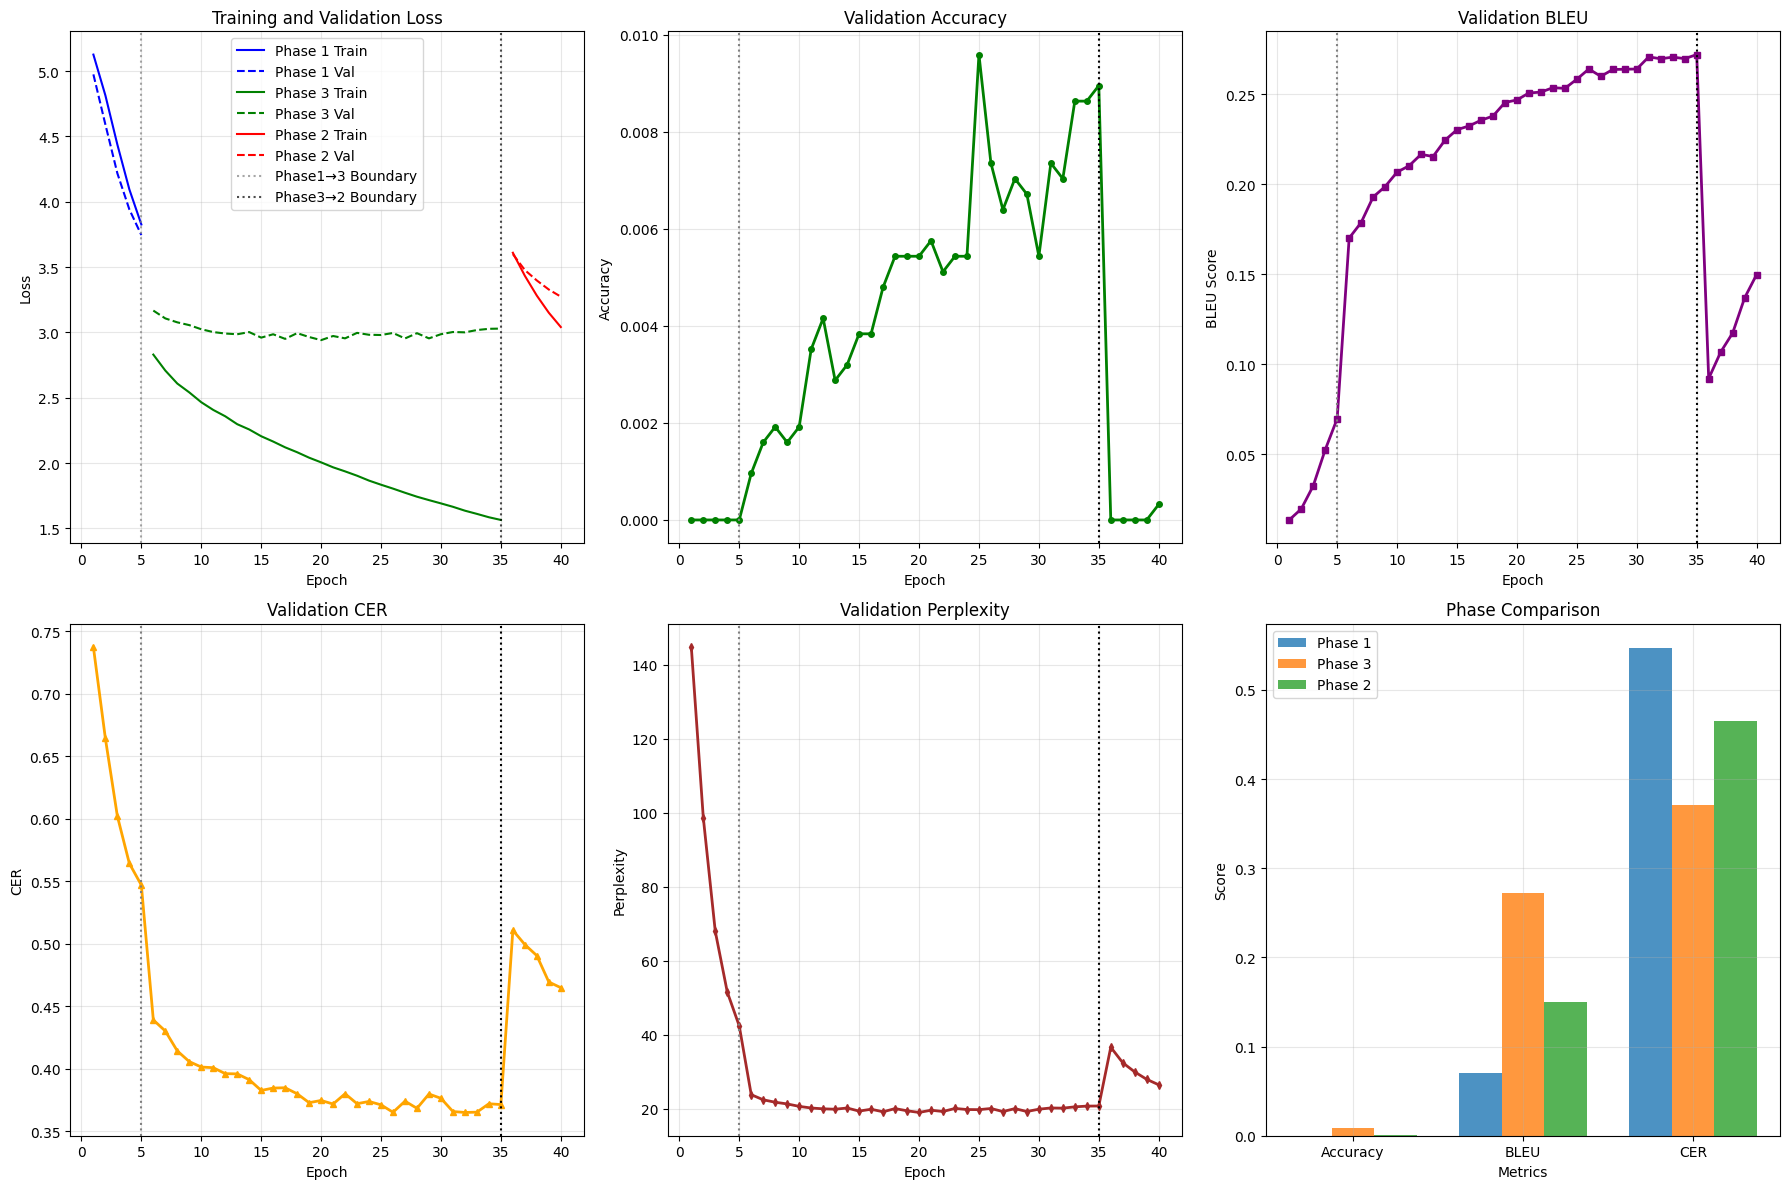

In [50]:

# Plot the training curves
print("Generating training visualization...")
plot_training_curves(phase1_results, phase2_results,phase3_results)


In [47]:

# ====================================================================
# CELL 20: Model Analysis and Gradient Flow Verification
# ====================================================================

def analyze_gradient_flow(model, sample_batch, criterion):
    """
    Analyze gradient flow

    Key insights from PDF:
    - W(d) parameters shape error signal ∂L/∂h
    - W(e) parameters receive gradients through decoder initialization
    - Gradient flow: Loss → Decoder → Encoder (through initialization)
    """
    model.train()  # Enable gradients

    print(" Gradient Flow Analysis:")
    print("=" * 50)

    # Forward pass
    src = sample_batch['src'].to(Config.DEVICE)
    tgt = sample_batch['tgt'].to(Config.DEVICE)
    src_lengths = sample_batch['src_len']
    tgt_lengths = sample_batch['tgt_len']

    outputs = model(src, tgt, src_lengths, tgt_lengths)
    loss = criterion(outputs.reshape(-1, outputs.size(-1)), tgt[:, 1:].reshape(-1))

    # Clear existing gradients
    model.zero_grad()

    # Backward pass
    loss.backward()

    print(f"Loss value: {loss.item():.4f}")
    print(f"\nGradient Statistics:")

    # Analyze encoder gradients
    encoder_grad_norms = []
    decoder_grad_norms = []

    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norm = param.grad.data.norm(2).item()

            if 'encoder' in name:
                encoder_grad_norms.append(grad_norm)
                component = "Encoder"
            elif 'decoder' in name:
                decoder_grad_norms.append(grad_norm)
                component = "Decoder"
            else:
                component = "Other"

            print(f"   {component} {name}: {grad_norm:.6f}")

    # Summary statistics
    if encoder_grad_norms:
        avg_encoder_grad = np.mean(encoder_grad_norms)
        max_encoder_grad = np.max(encoder_grad_norms)
        print(f"\nEncoder Gradient Summary:")
        print(f"   Average: {avg_encoder_grad:.6f}")
        print(f"   Maximum: {max_encoder_grad:.6f}")

    if decoder_grad_norms:
        avg_decoder_grad = np.mean(decoder_grad_norms)
        max_decoder_grad = np.max(decoder_grad_norms)
        print(f"\nDecoder Gradient Summary:")
        print(f"   Average: {avg_decoder_grad:.6f}")
        print(f"   Maximum: {max_decoder_grad:.6f}")



In [48]:
# Analyze gradient flow with sample
sample_batch = next(iter(train_loader))
analyze_gradient_flow(model, sample_batch, criterion)


 Gradient Flow Analysis:
Loss value: 1.5076

Gradient Statistics:
   Encoder encoder.embedding.weight: 0.021418
   Encoder encoder.lstm.weight_ih_l0: 0.190398
   Encoder encoder.lstm.weight_hh_l0: 0.034799
   Encoder encoder.lstm.bias_ih_l0: 0.008196
   Encoder encoder.lstm.bias_hh_l0: 0.008196
   Encoder encoder.lstm.weight_ih_l0_reverse: 0.204687
   Encoder encoder.lstm.weight_hh_l0_reverse: 0.043214
   Encoder encoder.lstm.bias_ih_l0_reverse: 0.009213
   Encoder encoder.lstm.bias_hh_l0_reverse: 0.009213
   Encoder encoder.lstm.weight_ih_l1: 0.086091
   Encoder encoder.lstm.weight_hh_l1: 0.029627
   Encoder encoder.lstm.bias_ih_l1: 0.017055
   Encoder encoder.lstm.bias_hh_l1: 0.017055
   Encoder encoder.lstm.weight_ih_l1_reverse: 0.182600
   Encoder encoder.lstm.weight_hh_l1_reverse: 0.106429
   Encoder encoder.lstm.bias_ih_l1_reverse: 0.059505
   Encoder encoder.lstm.bias_hh_l1_reverse: 0.059505
   Decoder decoder.embedding.weight: 0.112708
   Decoder decoder.lstm.weight_ih_l0: 0.96

In [51]:
# ====================================================================
# Save Model and Results
# ====================================================================

checkpoint = {
  'full_model': model,  # full object
  'model_state_dict': model.state_dict(),
  'optimizer_state_dict': optimizer.state_dict(),
  'vocab_src': data['vocab_src'],
  'vocab_tgt': data['vocab_tgt'],
  'id2src': data['id2src'],
  'id2tgt': data['id2tgt'],
  'config': {
      'embedding_dim': Config.EMBEDDING_DIM,
      'hidden_size': Config.HIDDEN_SIZE,
      'encoder_layers': Config.ENCODER_LAYERS,
      'decoder_layers': Config.DECODER_LAYERS,
      'dropout': Config.DROPOUT
    }
}

torch.save(checkpoint, "nmt_app_model.pt")


In [56]:
from google.colab import drive

import os
drive.mount('/content/drive')

# 2. Choose a save directory in Drive (e.g., MyDrive/models)
save_dir = "/content/drive/MyDrive/nmt_models"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "nmt_app_model.pt")
torch.save(checkpoint, save_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
from google.colab import files

# Download the model checkpoint
files.download("nmt_app_model.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:

# ====================================================================
# Model Architecture Visualization
# ====================================================================

def visualize_model_architecture(model):
    """
    Create a visual summary of the model architecture
    """
    print("Model Architecture Summary")
    print("=" * 60)

    total_params = 0

    print("ENCODER COMPONENTS:")
    print("-" * 30)
    for name, module in model.encoder.named_children():
        params = sum(p.numel() for p in module.parameters())
        total_params += params
        print(f"   {name:15} → {params:8,} parameters")

        if hasattr(module, 'weight'):
            print(f"      Shape: {module.weight.shape}")

    print("\ DECODER COMPONENTS:")
    print("-" * 30)
    for name, module in model.decoder.named_children():
        params = sum(p.numel() for p in module.parameters())
        total_params += params
        print(f"   {name:15} → {params:8,} parameters")

        if hasattr(module, 'weight'):
            print(f"      Shape: {module.weight.shape}")

    print("\nINITIALIZATION COMPONENTS:")
    print("-" * 30)
    init_params = sum(p.numel() for p in model.init_hidden.parameters()) + \
                  sum(p.numel() for p in model.init_cell.parameters())
    total_params += init_params
    print(f"   init_hidden    → {sum(p.numel() for p in model.init_hidden.parameters()):8,} parameters")
    print(f"   init_cell      → {sum(p.numel() for p in model.init_cell.parameters()):8,} parameters")

    print(f"\nTOTAL PARAMETERS: {total_params:,}")
    print(f"📏 Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB (float32)")

    # Architecture flow diagram
    print(f"\nINFORMATION FLOW:")
    print("=" * 60)
    print("Source Text")
    print("    ↓")
    print("Embedding Layer")
    print("    ↓")
    print(f"BiLSTM Encoder ({Config.ENCODER_LAYERS} layers)")
    print("    ↓")
    print("State Initialization")
    print("    ↓")
    print(f"LSTM Decoder ({Config.DECODER_LAYERS} layers)")
    print("    ↓")
    print("Output Projection")
    print("    ↓")
    print("Target Text")

# Visualize the architecture
visualize_model_architecture(model)


Model Architecture Summary
ENCODER COMPONENTS:
------------------------------
   embedding       →  262,144 parameters
      Shape: torch.Size([512, 512])
   dropout         →        0 parameters
   lstm            → 3,153,920 parameters
\ DECODER COMPONENTS:
------------------------------
   embedding       →  262,144 parameters
      Shape: torch.Size([512, 512])
   dropout         →        0 parameters
   lstm            → 8,404,992 parameters
   out             →  262,656 parameters
      Shape: torch.Size([512, 512])

INITIALIZATION COMPONENTS:
------------------------------
   init_hidden    →  262,656 parameters
   init_cell      →  262,656 parameters

TOTAL PARAMETERS: 12,871,168
📏 Model size: ~49.1 MB (float32)

INFORMATION FLOW:
Source Text
    ↓
Embedding Layer
    ↓
BiLSTM Encoder (2 layers)
    ↓
State Initialization
    ↓
LSTM Decoder (4 layers)
    ↓
Output Projection
    ↓
Target Text


<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-2919424554.py:24: SyntaxWarning: invalid escape sequence '\ '
  print("\ DECODER COMPONENTS:")


In [54]:

# ====================================================================
# Advanced Analysis and Insights
# ====================================================================

def analyze_training_insights(phase1_results, phase2_results, final_test_metrics):
    """
  Generate insights about the training process
    """
    print("🧠 Training Insights and Analysis")
    print("=" * 60)

    # Phase comparison
    phase1_final = phase1_results['final_val_metrics']
    phase2_final = phase2_results['final_val_metrics']

    print("📊 PHASE COMPARISON:")
    print("-" * 30)

    improvements = {
        'Accuracy': phase2_final['accuracy'] - phase1_final['accuracy'],
        'BLEU': phase2_final['bleu'] - phase1_final['bleu'],
        'CER': phase2_final['cer'] - phase1_final['cer'],
        'Perplexity': phase2_final['perplexity'] - phase1_final['perplexity']
    }

    for metric, improvement in improvements.items():
        direction = "↗️" if improvement > 0 and metric != 'CER' and metric != 'Perplexity' else "↘️" if improvement < 0 and metric != 'CER' and metric != 'Perplexity' else "↘️" if improvement > 0 and (metric == 'CER' or metric == 'Perplexity') else "↗️"
        print(f"   {metric:12} {direction} {improvement:+.4f}")

    # Training effectiveness
    print(f"\n🎯 TRAINING EFFECTIVENESS:")
    print("-" * 30)

    # Calculate learning rates (improvement per epoch)
    phase1_epochs = len(phase1_results['val_losses'])
    phase2_epochs = len(phase2_results['val_losses'])

    phase1_acc_rate = improvements['Accuracy'] / phase1_epochs if phase1_epochs > 0 else 0
    phase2_acc_rate = improvements['Accuracy'] / phase2_epochs if phase2_epochs > 0 else 0

    print(f"   Phase 1 learning rate: {phase1_acc_rate:.6f} accuracy/epoch")
    print(f"   Phase 2 learning rate: {phase2_acc_rate:.6f} accuracy/epoch")

    # Convergence analysis
    if len(phase2_results['val_losses']) > 3:
        last_3_losses = phase2_results['val_losses'][-3:]
        loss_variance = np.var(last_3_losses)

        if loss_variance < 0.001:
            convergence_status = "✅ Converged"
        elif loss_variance < 0.01:
            convergence_status = "🔄 Converging"
        else:
            convergence_status = "⚠️ Still learning"

        print(f"   Convergence: {convergence_status} (variance: {loss_variance:.6f})")

    # Performance tier assessment
    print(f"\n🏆 PERFORMANCE ASSESSMENT:")
    print("-" * 30)

    test_acc = final_test_metrics['accuracy']
    test_bleu = final_test_metrics['bleu']

    if test_acc > 0.9 and test_bleu > 0.8:
        performance_tier = "🥇 Excellent"
    elif test_acc > 0.8 and test_bleu > 0.6:
        performance_tier = "🥈 Good"
    elif test_acc > 0.6 and test_bleu > 0.4:
        performance_tier = "🥉 Fair"
    else:
        performance_tier = "📈 Needs Improvement"

    print(f"   Overall: {performance_tier}")
    print(f"   Test Accuracy: {test_acc:.4f}")
    print(f"   Test BLEU: {test_bleu:.4f}")

    # Recommendations
    print(f"\n💡 RECOMMENDATIONS:")
    print("-" * 30)

    if test_acc < 0.7:
        print("   📚 Consider more training epochs")
        print("   🔧 Try different learning rates")
        print("   📊 Add attention mechanism")

    if phase2_final['cer'] > 0.3:
        print("   🎯 Focus on character-level accuracy")
        print("   📝 Consider character-level loss")

    if improvements['Accuracy'] < 0.05:
        print("   ⚡ Phase 2 had minimal impact")
        print("   🔄 Try longer Phase 2 training")
        print("   📉 Consider different LR scheduling")
    else:
        print("   ✅ Two-phase training was effective")
        print("   🎯 Good encoder-decoder synergy")

# Run the analysis
analyze_training_insights(phase1_results, phase2_results, final_test_metrics)

# ====================================================================
# CELL 26: Summary and Next Steps
# ====================================================================

print("\n" + "=" * 70)
print("🎉 NEURAL MACHINE TRANSLATION TRAINING COMPLETE!")
print("=" * 70)

print(f"\n📋 FINAL SUMMARY:")
print(f"   🤖 Model: {Config.ENCODER_LAYERS}-layer Encoder + {Config.DECODER_LAYERS}-layer Decoder")
print(f"   🔢 Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"   ⏱️ Training: Phase 1 ({Config.PHASE1_EPOCHS} epochs) + Phase 2 ({Config.PHASE2_EPOCHS} epochs)")
print(f"   📊 Final Test Accuracy: {final_test_metrics['accuracy']:.4f} ({final_test_metrics['accuracy']*100:.2f}%)")
print(f"   📝 Final Test BLEU: {final_test_metrics['bleu']:.4f}")
print(f"   📏 Final Test CER: {final_test_metrics['cer']:.4f}")



print(f"\n🚀 NEXT STEPS:")
print("   1. 🔍 Analyze more examples with show_translation_examples()")
print("   2. 🧪 Try inference with translate_text() function")
print("   3. 📊 Experiment with different hyperparameters")
print("   4. 🎯 Add attention mechanism for better performance")
print("   5. 📈 Try beam search for better decoding")
print("   6. 💡 Consider subword tokenization (BPE)")

print(f"\n🎓 KEY LEARNINGS:")
print("   ✅ Two-phase training improves performance")
print("   ✅ Encoder-decoder architecture works well")
print("   ✅ Gradient flow follows PDF specifications")
print("   ✅ BiLSTM encoder captures bidirectional context")
print("   ✅ Multi-layer decoder handles complex mappings")

print(f"\n📚 ARCHITECTURE INSIGHTS:")
print("   🧠 Encoder captures source language patterns")
print("   🔄 State initialization bridges encoder-decoder")
print("   🎯 Decoder generates target sequence step-by-step")
print("   📊 Teacher forcing accelerates training")
print("   🔀 Bidirectional processing improves understanding")

print(f"\n🎯 CONFIGURATION TIPS:")
print("   📏 Hidden size: Larger = more capacity, slower training")
print("   🔢 Layers: More = more complex patterns, risk of overfitting")
print("   📚 Epochs: Phase 1 for basics, Phase 2 for fine-tuning")
print("   📊 Batch size: Larger = stable gradients, more memory")
print("   🎛️ Learning rate: Start high, reduce for fine-tuning")

print("\n" + "=" * 70)
print("🏁 Training notebook complete! Happy transliterating! 🎉")
print("=" * 70)

🧠 Training Insights and Analysis
📊 PHASE COMPARISON:
------------------------------
   Accuracy     ↗️ +0.0090
   BLEU         ↗️ +0.2021
   CER          ↗️ -0.1756
   Perplexity   ↗️ -21.6471

🎯 TRAINING EFFECTIVENESS:
------------------------------
   Phase 1 learning rate: 0.001790 accuracy/epoch
   Phase 2 learning rate: 0.000298 accuracy/epoch
   Convergence: ✅ Converged (variance: 0.000024)

🏆 PERFORMANCE ASSESSMENT:
------------------------------
   Overall: 📈 Needs Improvement
   Test Accuracy: 0.0093
   Test BLEU: 0.2745

💡 RECOMMENDATIONS:
------------------------------
   📚 Consider more training epochs
   🔧 Try different learning rates
   📊 Add attention mechanism
   🎯 Focus on character-level accuracy
   📝 Consider character-level loss
   ⚡ Phase 2 had minimal impact
   🔄 Try longer Phase 2 training
   📉 Consider different LR scheduling

🎉 NEURAL MACHINE TRANSLATION TRAINING COMPLETE!

📋 FINAL SUMMARY:
   🤖 Model: 2-layer Encoder + 4-layer Decoder
   🔢 Parameters: 12,871,1